# Machine Learning Course  
## Lesson 07 — K-Nearest Neighbors

**Previous lesson:** Ridge and Lasso Regression  
**Next lesson:** Support Vector Machines

### Lesson Focus

Distance-based classification, scaling, and model evaluation.

### Learning Objectives

By the end of this notebook, learners should be able to:

- explain the central concepts presented in this lesson;
- implement the relevant method using Python;
- evaluate the resulting model or computation appropriately;
- interpret outputs rather than reporting values without context;
- identify common implementation and modeling mistakes.

### Prerequisites

Familiarity with Python, NumPy, pandas, Matplotlib, and the concepts introduced in the preceding lesson.

### Reproducibility Standard

All data splits and stochastic estimators should use a fixed random seed. Preprocessing must be learned from training data only, preferably through a pipeline.

There is a Car manufacturer company that has manufactured a new SUV car. The company wants to give the ads to the users who are interested in buying that SUV. So for this problem, we have a dataset that contains multiple user's information through the social network. The dataset contains lots of information but the Estimated Salary and Age we will consider for the independent variable and the Purchased variable is for the dependent variable. Below is the dataset:

## **Data Pre-Processing Step:**

In [1]:
# importing libraries
import numpy as nm
import matplotlib.pyplot as mtp
import pandas as pd

In [2]:
from pathlib import Path

possible_paths = [
    Path("Car_Data.csv"),
    Path("Data") / "Car_Data.csv",
    Path("data") / "Car_Data.csv",
    Path("datasets") / "Car_Data.csv",
    Path("..") / "Data" / "Car_Data.csv",
    Path("..") / "data" / "Car_Data.csv",
    Path("..") / "datasets" / "Car_Data.csv",
]

DATA_PATH = next((path for path in possible_paths if path.exists()), None)

if DATA_PATH is None:
    searched_paths = "\n".join(
        str(path.resolve()) for path in possible_paths
    )

    raise FileNotFoundError(
        "bank_note_data.txt was not found.\n"
        f"Current working directory: {Path.cwd()}\n\n"
        f"Searched:\n{searched_paths}"
    )

print(f"Loading dataset from: {DATA_PATH.resolve()}")



Loading dataset from: D:\GitHub\Python-Code\Machine-Learning-Course\datasets\Car_Data.csv


In [3]:
#importing datasets
data_set= pd.read_csv(DATA_PATH)
data_set

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [4]:
#Extracting Independent and dependent Variable
x= data_set.iloc[:, [2,3]].values
y= data_set.iloc[:, 4].values

# Splitting the dataset into training and test set.
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.25, random_state=0)

#feature Scaling
from sklearn.preprocessing import StandardScaler
st_x= StandardScaler()
x_train= st_x.fit_transform(x_train)
x_test= st_x.transform(x_test)

In [5]:
x_test

array([[-0.80480212,  0.50496393],
       [-0.01254409, -0.5677824 ],
       [-0.30964085,  0.1570462 ],
       [-0.80480212,  0.27301877],
       [-0.30964085, -0.5677824 ],
       [-1.10189888, -1.43757673],
       [-0.70576986, -1.58254245],
       [-0.21060859,  2.15757314],
       [-1.99318916, -0.04590581],
       [ 0.8787462 , -0.77073441],
       [-0.80480212, -0.59677555],
       [-1.00286662, -0.42281668],
       [-0.11157634, -0.42281668],
       [ 0.08648817,  0.21503249],
       [-1.79512465,  0.47597078],
       [-0.60673761,  1.37475825],
       [-0.11157634,  0.21503249],
       [-1.89415691,  0.44697764],
       [ 1.67100423,  1.75166912],
       [-0.30964085, -1.37959044],
       [-0.30964085, -0.65476184],
       [ 0.8787462 ,  2.15757314],
       [ 0.28455268, -0.53878926],
       [ 0.8787462 ,  1.02684052],
       [-1.49802789, -1.20563157],
       [ 1.07681071,  2.07059371],
       [-1.00286662,  0.50496393],
       [-0.90383437,  0.30201192],
       [-0.11157634,

From the above output, we can see that our data is successfully scaled.

In [6]:
y_test

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1])

Fitting K-NN classifier to the Training data:
Now we will fit the K-NN classifier to the training data. To do this we will import the KNeighborsClassifier class of Sklearn Neighbors library. After importing the class, we will create the Classifier object of the class. The Parameter of this class will be
* n_neighbors:  To define the required neighbors of the
algorithm. Usually, it takes 5.
* metric='minkowski': This is the default parameter and it decides the distance between the points.
* p=2: It is equivalent to the standard Euclidean metric.
And then we will fit the classifier to the training data. Below is the code for it:

In [7]:
#Fitting K-NN classifier to the training set
from sklearn.neighbors import KNeighborsClassifier
classifier= KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2 )
classifier.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


Predicting the Test Result: To predict the test set result, we will create a y_pred vector as we did in Logistic Regression. Below is the code for it:

In [8]:
#Predicting the test set result
y_pred= classifier.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1])

**Creating the Confusion Matrix:**

Now we will create the Confusion Matrix for our K-NN model to see the accuracy of the classifier. Below is the code for it:

In [9]:
#Creating the Confusion matrix
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(y_test, y_pred)

In above code, we have imported the confusion_matrix function and called it using the variable cm.

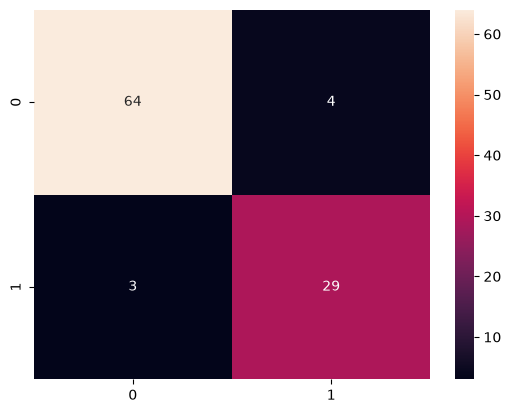

In [10]:
import seaborn as sn
sn.heatmap(cm, annot=True)
mtp.show()

In the above image, we can see there are 64+29= 93 correct predictions and 3+4= 7 incorrect predictions.

**Visualizing the Training set result:**

C:\Users\emans\AppData\Local\Temp\ipykernel_139436\59563456.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  mtp.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],


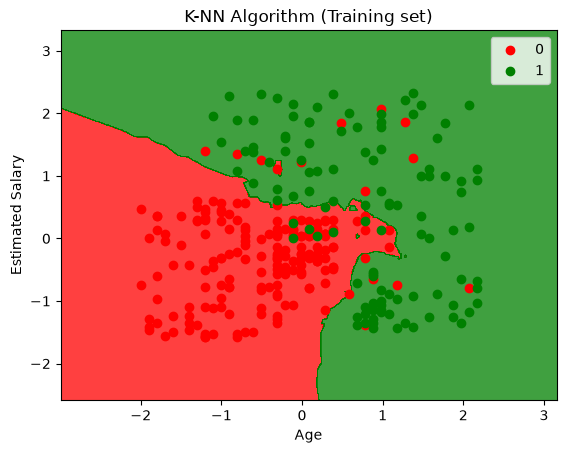

In [11]:
#Visulaizing the trianing set result
from matplotlib.colors import ListedColormap
x_set, y_set = x_train, y_train
x1, x2 = nm.meshgrid(nm.arange(start = x_set[:, 0].min() - 1, stop = x_set[:, 0].max() + 1, step  =0.01),
nm.arange(start = x_set[:, 1].min() - 1, stop = x_set[:, 1].max() + 1, step = 0.01))
mtp.contourf(x1, x2, classifier.predict(nm.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
alpha = 0.75, cmap = ListedColormap(('red','green' )))
mtp.xlim(x1.min(), x1.max())
mtp.ylim(x2.min(), x2.max())
for i, j in enumerate(nm.unique(y_set)):
    mtp.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],
        c = ListedColormap(('red', 'green'))(i), label = j)
mtp.title('K-NN Algorithm (Training set)')
mtp.xlabel('Age')
mtp.ylabel('Estimated Salary')
mtp.legend()
mtp.show()

* As we can see the graph is showing the red point and green points. The green points are for Purchased(1) and Red Points for not Purchased(0) variable.
* The graph is showing an irregular boundary instead of showing any straight line or any curve because it is a K-NN algorithm, i.e., finding the nearest neighbor.
* The graph has classified users in the correct categories as most of the users who didn't buy the SUV are in the red region and users who bought the SUV are in the green region.
* The graph is showing good result but still, there are some green points in the red region and red points in the green region. But this is no big issue as by doing this model is prevented from overfitting issues.
Hence our model is well trained.

**Visualizing the Test set result:**

After the training of the model, we will now test the result by putting a new dataset, i.e., Test dataset. Code remains the same except some minor changes: such as x_train and y_train will be replaced by x_test and y_test.
Below is the code for it:

C:\Users\emans\AppData\Local\Temp\ipykernel_139436\1216317106.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  mtp.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],


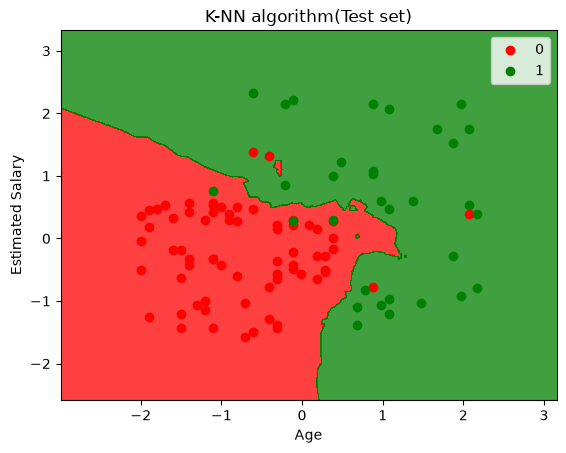

In [12]:
#Visualizing the test set result
from matplotlib.colors import ListedColormap
x_set, y_set = x_test, y_test
x1, x2 = nm.meshgrid(nm.arange(start = x_set[:, 0].min() - 1, stop = x_set[:, 0].max() + 1, step  =0.01),
nm.arange(start = x_set[:, 1].min() - 1, stop = x_set[:, 1].max() + 1, step = 0.01))
mtp.contourf(x1, x2, classifier.predict(nm.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
alpha = 0.75, cmap = ListedColormap(('red','green' )))
mtp.xlim(x1.min(), x1.max())
mtp.ylim(x2.min(), x2.max())
for i, j in enumerate(nm.unique(y_set)):
    mtp.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],
        c = ListedColormap(('red', 'green'))(i), label = j)
mtp.title('K-NN algorithm(Test set)')
mtp.xlabel('Age')
mtp.ylabel('Estimated Salary')
mtp.legend()
mtp.show()

## Lesson Review

### Key Takeaways

- The method should be understood through both its mathematical objective and its implementation.
- Evaluation must use data that were not used to fit the model.
- Preprocessing, model selection, and interpretation are part of the modeling workflow.
- Strong performance metrics do not replace error analysis or domain-aware interpretation.

### Exercises

1. Re-run the main experiment with a different random seed and compare the results.
2. Identify the most important modeling assumption in this lesson.
3. Add at least one additional evaluation metric or diagnostic visualization.
4. Explain one circumstance in which the demonstrated method would be unsuitable.
5. Convert the main workflow into a reusable scikit-learn pipeline where applicable.

### References

- scikit-learn user guide and API documentation
- NumPy and pandas documentation
- James, Witten, Hastie, and Tibshirani, *An Introduction to Statistical Learning*
- Géron, *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*

---

**Next lesson:** Support Vector Machines